# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

In [1]:
import pandas as pd

cms_df = pd.read_csv(
    "2014-2024 Original Medicare Geographic Variation Public Use File.csv"
)

cms_df.head()

/tmp/ipykernel_53/261451873.py:3: DtypeWarning: Columns (222,223) have mixed types. Specify dtype option on import or set low_memory=False.
  cms_df = pd.read_csv(


,YEAR,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL,BENES_TOTAL_CNT,BENES_WTH_PTAPTB_CNT,BENES_OM_CNT,BENES_MA_CNT,MA_PRTCPTN_RATE,...,PQI11_BCTRL_PNA_AGE_LT_65,PQI11_BCTRL_PNA_AGE_65_74,PQI11_BCTRL_PNA_AGE_GE_75,PQI12_UTI_AGE_LT_65,PQI12_UTI_AGE_65_74,PQI12_UTI_AGE_GE_75,PQI15_ASTHMA_AGE_LT_40,PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65,PQI16_LWRXTRMTY_AMPUTN_AGE_65_74,PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75
0,2014,National,National,NaN,All,56767775,49302821,33462969,15839852,0.3213,...,686,499,1373,361,269,1120,286,147,50,47
1,2014,National,National,NaN,<65,9286837,7824336,5867170,1957166,0.2501,...,686,NaN,NaN,361,NaN,NaN,286,147,NaN,NaN
2,2014,National,National,NaN,>=65,47480938,41478485,27595799,13882686,0.3347,...,NaN,499,1373,NaN,269,1120,NaN,NaN,50,47
3,2014,State,AK,2.0,All,84573,71860,71383,477,0.0066,...,622,366,1271,181,152,703,*,130,*,72
4,2014,State,AK,2.0,<65,13294,11641,11578,63,0.0054,...,622,NaN,NaN,181,NaN,NaN,*,130,NaN,NaN


### **1.1.** Problem Statement

Emergency room use varies across counties and may be related to local economic conditions. This project combines county-level Medicare utilization data from the CMS Geographic Variation Public Use File with median household income data from the U.S. Census Bureau American Community Survey to examine whether income is associated with emergency room visits per 1,000 Medicare beneficiaries.

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**

Type: CSV File

Method: The data was gathered by manually downloading the CMS Medicare Geographic Variation Public Use File from the Centers for Medicare & Medicaid Services (CMS) website and loading it into the notebook using pandas. This dataset was selected because it provides county-level Medicare utilization measures needed to analyze emergency room visit rates across the United States.

Dataset variables:

BENE_GEO_CD: Five-digit county FIPS code used to identify and merge county records.
BENES_TOTAL_CNT: Total number of Medicare beneficiaries in each county.
ER_VISITS_PER_1000_BENES: Emergency room visits per 1,000 Medicare beneficiaries.

In [2]:
cms_df = pd.read_csv(
    "2014-2024 Original Medicare Geographic Variation Public Use File.csv"
)

cms_df.head()

/tmp/ipykernel_53/3964762465.py:1: DtypeWarning: Columns (222,223) have mixed types. Specify dtype option on import or set low_memory=False.
  cms_df = pd.read_csv(


,YEAR,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL,BENES_TOTAL_CNT,BENES_WTH_PTAPTB_CNT,BENES_OM_CNT,BENES_MA_CNT,MA_PRTCPTN_RATE,...,PQI11_BCTRL_PNA_AGE_LT_65,PQI11_BCTRL_PNA_AGE_65_74,PQI11_BCTRL_PNA_AGE_GE_75,PQI12_UTI_AGE_LT_65,PQI12_UTI_AGE_65_74,PQI12_UTI_AGE_GE_75,PQI15_ASTHMA_AGE_LT_40,PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65,PQI16_LWRXTRMTY_AMPUTN_AGE_65_74,PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75
0,2014,National,National,NaN,All,56767775,49302821,33462969,15839852,0.3213,...,686,499,1373,361,269,1120,286,147,50,47
1,2014,National,National,NaN,<65,9286837,7824336,5867170,1957166,0.2501,...,686,NaN,NaN,361,NaN,NaN,286,147,NaN,NaN
2,2014,National,National,NaN,>=65,47480938,41478485,27595799,13882686,0.3347,...,NaN,499,1373,NaN,269,1120,NaN,NaN,50,47
3,2014,State,AK,2.0,All,84573,71860,71383,477,0.0066,...,622,366,1271,181,152,703,*,130,*,72
4,2014,State,AK,2.0,<65,13294,11641,11578,63,0.0054,...,622,NaN,NaN,181,NaN,NaN,*,130,NaN,NaN


#### Dataset 2

Type: API

Method: The data was gathered from the U.S. Census Bureau American Community Survey 5-Year API using the requests library. This dataset was selected because it provides county-level demographic measures that can be compared with Medicare emergency room utilization.

Dataset variables:

Median_Income: Median household income for each county.
Population: Total county population.
People_In_Poverty: Number of people living below the poverty level.
state and county: FIPS components used to create the five-digit county identifier for merging.

In [3]:
import requests

API_KEY = "3275288e9b9e4430ae3b0fc1eabd591c7f594e92"

url = (
    "https://api.census.gov/data/2015/acs/acs5"
    "?get=NAME,B01003_001E,B19013_001E,B17001_002E"
    "&for=county:*"
    "&in=state:*"
    f"&key={API_KEY}"
)

response = requests.get(url)
response.raise_for_status()

census_data = response.json()

census_df = pd.DataFrame(
    census_data[1:],
    columns=census_data[0]
)

census_df.head()

,NAME,B01003_001E,B19013_001E,B17001_002E,state,county
0,"Childress County, Texas",7059,36633,1177,48,075
1,"Comal County, Texas",119632,65833,10423,48,091
2,"Houston County, Texas",22949,32698,4918,48,225
3,"Navarro County, Texas",48118,41505,9794,48,349
4,"Scurry County, Texas",17238,56842,1527,48,415


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [4]:
cms_df.to_csv("cms_raw.csv", index=False)
census_df.to_csv("census_raw.csv", index=False)

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:

In [5]:
cms_df.head()

,YEAR,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL,BENES_TOTAL_CNT,BENES_WTH_PTAPTB_CNT,BENES_OM_CNT,BENES_MA_CNT,MA_PRTCPTN_RATE,...,PQI11_BCTRL_PNA_AGE_LT_65,PQI11_BCTRL_PNA_AGE_65_74,PQI11_BCTRL_PNA_AGE_GE_75,PQI12_UTI_AGE_LT_65,PQI12_UTI_AGE_65_74,PQI12_UTI_AGE_GE_75,PQI15_ASTHMA_AGE_LT_40,PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65,PQI16_LWRXTRMTY_AMPUTN_AGE_65_74,PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75
0,2014,National,National,NaN,All,56767775,49302821,33462969,15839852,0.3213,...,686,499,1373,361,269,1120,286,147,50,47
1,2014,National,National,NaN,<65,9286837,7824336,5867170,1957166,0.2501,...,686,NaN,NaN,361,NaN,NaN,286,147,NaN,NaN
2,2014,National,National,NaN,>=65,47480938,41478485,27595799,13882686,0.3347,...,NaN,499,1373,NaN,269,1120,NaN,NaN,50,47
3,2014,State,AK,2.0,All,84573,71860,71383,477,0.0066,...,622,366,1271,181,152,703,*,130,*,72
4,2014,State,AK,2.0,<65,13294,11641,11578,63,0.0054,...,622,NaN,NaN,181,NaN,NaN,*,130,NaN,NaN


In [6]:
cms_df[
    [
        "BENE_GEO_CD",
        "BENES_TOTAL_CNT",
        "ER_VISITS_PER_1000_BENES"
    ]
].isnull().sum()

BENE_GEO_CD                 99
BENES_TOTAL_CNT              0
ER_VISITS_PER_1000_BENES     0
dtype: int64

**Issue**: The CMS dataset contains missing values in variables used for the analysis, including the county FIPS code, total Medicare beneficiaries, and emergency room visits per 1,000 beneficiaries. These missing values would prevent accurate merging with the Census dataset and could affect the analysis if left untreated.

**Justification**: The data was assessed visually with head() to confirm the structure and programmatically with isnull().sum() to identify and count missing values in the variables required for the analysis.

### Quality Issue 2:

In [7]:
census_df.head()

,NAME,B01003_001E,B19013_001E,B17001_002E,state,county
0,"Childress County, Texas",7059,36633,1177,48,075
1,"Comal County, Texas",119632,65833,10423,48,091
2,"Houston County, Texas",22949,32698,4918,48,225
3,"Navarro County, Texas",48118,41505,9794,48,349
4,"Scurry County, Texas",17238,56842,1527,48,415


In [8]:
census_df.info()

census_df[
    [
        "B01003_001E",
        "B19013_001E",
        "B17001_002E",
    ]
].isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3220 entries, 0 to 3219
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   NAME         3220 non-null   object
 1   B01003_001E  3220 non-null   object
 2   B19013_001E  3219 non-null   object
 3   B17001_002E  3220 non-null   object
 4   state        3220 non-null   object
 5   county       3220 non-null   object
dtypes: object(6)
memory usage: 151.1+ KB


B01003_001E    0
B19013_001E    1
B17001_002E    0
dtype: int64

**Issue**: The Census dataset stores population, median household income, and poverty values as object data types instead of numeric values. These variables must be converted to numeric before they can be analyzed or merged with other datasets.

**Justification**: The dataset was inspected visually using head() to review the data structure and programmatically using info() and isnull().sum() to identify the data types and check for missing values in the variables used for the analysis.

### Tidiness Issue 1:

In [9]:
census_df.head()

,NAME,B01003_001E,B19013_001E,B17001_002E,state,county
0,"Childress County, Texas",7059,36633,1177,48,075
1,"Comal County, Texas",119632,65833,10423,48,091
2,"Houston County, Texas",22949,32698,4918,48,225
3,"Navarro County, Texas",48118,41505,9794,48,349
4,"Scurry County, Texas",17238,56842,1527,48,415


In [10]:
census_df[["state", "county"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3220 entries, 0 to 3219
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   state   3220 non-null   object
 1   county  3220 non-null   object
dtypes: object(2)
memory usage: 50.4+ KB


**Issue**: The Census dataset stores the county identifier in two separate columns (state and county). The CMS dataset uses a single five-digit county FIPS code (BENE_GEO_CD), so the Census identifiers must be combined before the datasets can be merged.

**Justification**: The data was assessed visually with head() to examine the column layout and programmatically with info() to verify that the state and county FIPS components exist as separate variables. This confirmed that the data structure needed to be adjusted before merging.

### Tidiness Issue 2: 

In [11]:
cms_df.head()

census_df.head()

,NAME,B01003_001E,B19013_001E,B17001_002E,state,county
0,"Childress County, Texas",7059,36633,1177,48,075
1,"Comal County, Texas",119632,65833,10423,48,091
2,"Houston County, Texas",22949,32698,4918,48,225
3,"Navarro County, Texas",48118,41505,9794,48,349
4,"Scurry County, Texas",17238,56842,1527,48,415


In [12]:
print(cms_df.shape)
print(census_df.shape)

(36994, 246)
(3220, 6)


**Issue**: The CMS and Census data are stored in separate datasets, but the research question requires information from both sources. The datasets must be merged using a common county FIPS code to create a single tidy dataset for analysis.

**Justification**: The datasets were assessed visually with head() to compare their structures and programmatically with shape to confirm they were separate datasets containing different variables. This showed that combining them was necessary before performing the analysis.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [13]:
# Make copies of the datasets so the raw data is not modified

cms_clean = cms_df.copy()
census_clean = census_df.copy()

**Quality Issue 1: Missing values in key CMS variables**

In [14]:
cms_clean = cms_clean.dropna(
    subset=[
        "BENE_GEO_CD",
        "BENES_TOTAL_CNT",
        "ER_VISITS_PER_1000_BENES",
    ]
).copy()

In [15]:
cms_clean[
    [
        "BENE_GEO_CD",
        "BENES_TOTAL_CNT",
        "ER_VISITS_PER_1000_BENES",
    ]
].isnull().sum()

BENE_GEO_CD                 0
BENES_TOTAL_CNT             0
ER_VISITS_PER_1000_BENES    0
dtype: int64

**Justification**: Rows with missing values in the variables required for the analysis were removed because they could not be used for merging or evaluating the relationship between county income and emergency room visit rates. Removing these incomplete records ensures that only complete observations are included in the final analysis.

**Quality Issue 2: Census numeric variables stored as object data types**

In [16]:
# Rename the Census variables used in the analysis

census_clean = census_clean.rename(
    columns={
        "NAME": "County",
        "B01003_001E": "Population",
        "B19013_001E": "Median_Income",
        "B17001_002E": "People_In_Poverty"
    }
)

# Convert the analysis variables to numeric

census_clean[
    [
        "Population",
        "Median_Income",
        "People_In_Poverty",
    ]
] = census_clean[
    [
        "Population",
        "Median_Income",
        "People_In_Poverty",
    ]
].apply(pd.to_numeric, errors="coerce")

In [17]:
census_clean[
    [
        "Population",
        "Median_Income",
        "People_In_Poverty",
    ]
].dtypes

Population             int64
Median_Income        float64
People_In_Poverty      int64
dtype: object

Justification: The Census variables used in the analysis were converted from object data types to numeric values so they can be analyzed and compared with the CMS data. Numeric data types are required for calculations, visualizations, and statistical analysis.

**Tidiness Issue 1: County FIPS code stored in separate columns**

In [18]:
# Rename FIPS columns

census_clean = census_clean.rename(
    columns={
        "state": "State_FIPS",
        "county": "County_FIPS"
    }
)

# Create a single five-digit county FIPS code

census_clean["BENE_GEO_CD"] = (
    census_clean["State_FIPS"].astype(str).str.zfill(2)
    + census_clean["County_FIPS"].astype(str).str.zfill(3)
)

In [19]:
census_clean[
    ["State_FIPS", "County_FIPS", "BENE_GEO_CD"]
].head()

,State_FIPS,County_FIPS,BENE_GEO_CD
0,48,075,48075
1,48,091,48091
2,48,225,48225
3,48,349,48349
4,48,415,48415


Justification: The state and county FIPS codes were combined into a single five-digit county identifier (BENE_GEO_CD) so the Census data matches the identifier used in the CMS dataset. Creating a common key makes it possible to merge the two datasets accurately.

**Tidiness Issue 2: Datasets contain unnecessary variables for the analysis**

In [20]:
# Keep only the variables needed for the analysis

cms_subset = cms_clean[
    (cms_clean["YEAR"] == 2015) &
    (cms_clean["BENE_GEO_LVL"] == "County")
][
    [
        "YEAR",
        "BENE_GEO_LVL",
        "BENE_GEO_DESC",
        "BENE_GEO_CD",
        "BENES_TOTAL_CNT",
        "ER_VISITS_PER_1000_BENES",
    ]
].copy()

census_subset = census_clean[
    [
        "BENE_GEO_CD",
        "County",
        "Population",
        "Median_Income",
        "People_In_Poverty",
    ]
].copy()

In [21]:
print(cms_subset.shape)
print(census_subset.shape)

cms_subset.head()

census_subset.head()

(3195, 6)
(3220, 5)


,BENE_GEO_CD,County,Population,Median_Income,People_In_Poverty
0,48075,"Childress County, Texas",7059,36633.0,1177
1,48091,"Comal County, Texas",119632,65833.0,10423
2,48225,"Houston County, Texas",22949,32698.0,4918
3,48349,"Navarro County, Texas",48118,41505.0,9794
4,48415,"Scurry County, Texas",17238,56842.0,1527


Justification: Only the variables needed to answer the research question were retained. Removing unnecessary variables simplifies the datasets, reduces clutter, and makes the merged dataset easier to analyze.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [22]:
# Make sure both county FIPS columns use the same five-digit string format

cms_subset["BENE_GEO_CD"] = (
    pd.to_numeric(cms_subset["BENE_GEO_CD"], errors="coerce")
    .astype("Int64")
    .astype(str)
    .str.zfill(5)
)

census_subset["BENE_GEO_CD"] = (
    census_subset["BENE_GEO_CD"]
    .astype(str)
    .str.zfill(5)
)

# Combine the cleaned datasets

merged_df = pd.merge(
    cms_subset,
    census_subset,
    on="BENE_GEO_CD",
    how="inner"
)

print(merged_df.shape)
merged_df.head()

(3141, 10)


,YEAR,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENES_TOTAL_CNT,ER_VISITS_PER_1000_BENES,County,Population,Median_Income,People_In_Poverty
0,2015,County,AK-Aleutians East,02013,166,*,"Aleutians East Borough, Alaska",3304,61518.0,553
1,2015,County,AK-Aleutians West,02016,239,104.8951,"Aleutians West Census Area, Alaska",5684,84306.0,499
2,2015,County,AK-Anchorage,02020,34768,606.9714,"Anchorage Municipality, Alaska",299107,78326.0,23914
3,2015,County,AK-Bethel,02050,1340,60.4089,"Bethel Census Area, Alaska",17776,51012.0,4364
4,2015,County,AK-Bristol Bay,02060,127,247.619,"Bristol Bay Borough, Alaska",970,79750.0,69


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [23]:
# Save raw datasets and cleaned combined dataset

cms_df.to_csv("cms_raw.csv", index=False)
census_df.to_csv("census_raw.csv", index=False)
merged_df.to_csv("cms_census_cleaned.csv", index=False)

print("Raw and cleaned datasets saved successfully.")

Raw and cleaned datasets saved successfully.


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* Is there a relationship between median household income and emergency room visits per 1,000 Medicare beneficiaries at the county level in the United States?

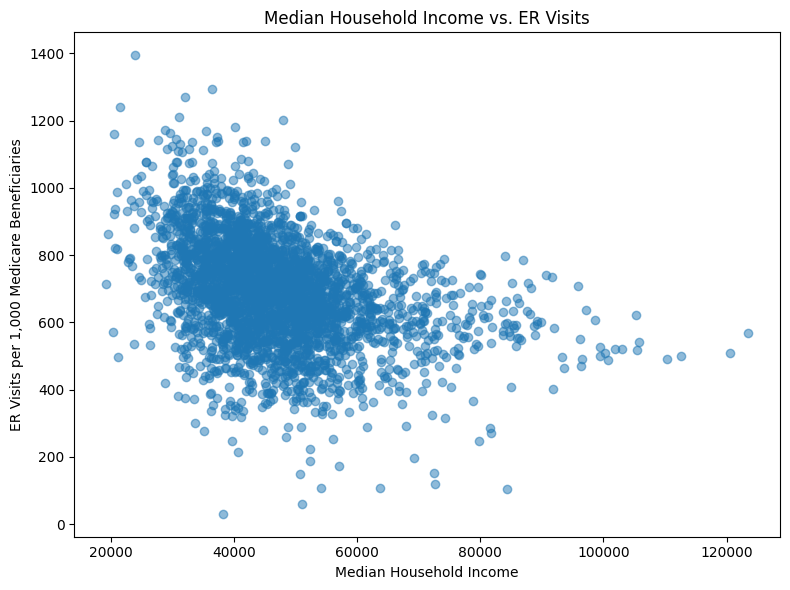

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert plotting columns to numeric
plot_df = merged_df[
    ["Median_Income", "ER_VISITS_PER_1000_BENES"]
].copy()

plot_df["Median_Income"] = pd.to_numeric(
    plot_df["Median_Income"],
    errors="coerce"
)

plot_df["ER_VISITS_PER_1000_BENES"] = pd.to_numeric(
    plot_df["ER_VISITS_PER_1000_BENES"],
    errors="coerce"
)

# Remove rows that cannot be plotted
plot_df = plot_df.dropna()

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["Median_Income"],
    plot_df["ER_VISITS_PER_1000_BENES"],
    alpha=0.5
)

plt.xlabel("Median Household Income")
plt.ylabel("ER Visits per 1,000 Medicare Beneficiaries")
plt.title("Median Household Income vs. ER Visits")
plt.tight_layout()
plt.show()

*Answer to research question:* The scatter plot shows the relationship between county median household income and emergency room visits. Counties with lower median household incomes generally tend to have higher emergency room visit rates, though there is considerable variation across counties.

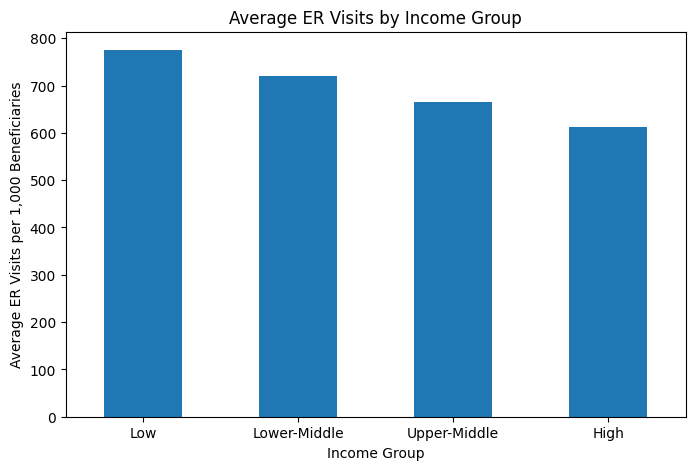

In [25]:
import matplotlib.pyplot as plt

# Convert the variables used in the chart to numeric
merged_df["Median_Income"] = pd.to_numeric(
    merged_df["Median_Income"],
    errors="coerce"
)

merged_df["ER_VISITS_PER_1000_BENES"] = pd.to_numeric(
    merged_df["ER_VISITS_PER_1000_BENES"],
    errors="coerce"
)

# Remove rows that cannot be used in this chart
plot_df = merged_df.dropna(
    subset=[
        "Median_Income",
        "ER_VISITS_PER_1000_BENES"
    ]
).copy()

# Divide counties into four income groups
plot_df["Income_Group"] = pd.qcut(
    plot_df["Median_Income"],
    q=4,
    labels=["Low", "Lower-Middle", "Upper-Middle", "High"]
)

# Calculate the average ER visit rate for each income group
income_group_means = (
    plot_df.groupby("Income_Group", observed=False)[
        "ER_VISITS_PER_1000_BENES"
    ]
    .mean()
)

income_group_means.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Income Group")
plt.ylabel("Average ER Visits per 1,000 Beneficiaries")
plt.title("Average ER Visits by Income Group")
plt.xticks(rotation=0)
plt.show()

*Answer to research question:* The bar chart compares the average emergency room visit rate across four income groups. Counties in the lowest income group have higher average emergency room visit rates than counties in the highest income group, supporting the observation that lower-income counties generally experience greater emergency room utilization.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* If I had more time, I would investigate additional factors that may influence emergency room utilization, such as age, chronic disease prevalence, and access to healthcare providers. I would also examine regional differences and use statistical methods, such as correlation or regression analysis, to better measure the relationship between median household income and emergency room visit rates. This could provide a more detailed understanding of the factors associated with emergency room use.